# Mean-Variance Optimization

**Docker image**: `ml4t`

This notebook demonstrates Modern Portfolio Theory (MPT) and mean-variance optimization,
showing how to construct efficient frontiers, find optimal portfolios, and understand
the practical limitations of classical MVO (the "Markowitz Curse").

**Learning Objectives**:
- Implement MVO using `scipy.optimize` to find maximum Sharpe and minimum variance portfolios
- Construct and visualize the efficient frontier from historical data
- Analyze covariance matrix condition numbers to assess estimation stability
- Compare optimized portfolios to heuristic baselines (equal weight, inverse vol, equal risk contribution)

**Book Reference**: Chapter 17, §17.5 (Mean-Variance Optimization and the Markowitz Curse)

**Prerequisites**: ETF price data from Ch2

## The Mean-Variance Framework

MPT solves for the optimal portfolio weights to minimize volatility for a given expected return, or maximize returns for a given level of volatility. The key requisite inputs are expected asset returns, standard deviations, and the covariance matrix.

Diversification works because the variance of portfolio returns depends on the covariance of the assets and can be reduced below the weighted average of the asset variances by including assets with less than perfect correlation. Given a vector, $\omega$, of portfolio weights and the covariance matrix, $\Sigma$, the portfolio variance, $\sigma_{\text{PF}}^2$ is:

$$\sigma_{\text{PF}}^2=\omega^T\Sigma\omega$$

Markowitz showed that maximizing expected portfolio return subject to a target risk has an equivalent dual representation of minimizing portfolio risk subject to a target expected return level, $\mu_{PF}$:

$$
\begin{align}
\min_\omega & \quad\quad\sigma^2_{\text{PF}}= \omega^T\Sigma\omega\\
\text{s.t.} &\quad\quad \mu_{\text{PF}}= \omega^T\mu\\
&\quad\quad \mathbf{1}^\top \omega =1
\end{align}
$$

We calculate an efficient frontier using `scipy.optimize.minimize` and historical estimates for asset returns, standard deviations, and the covariance matrix.

In [1]:
"""Mean-Variance Optimization — construct efficient frontiers and optimize portfolios using historical return estimates."""

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import (
    PortfolioAnalysis,
)
from ml4t.diagnostic.evaluation.factor import FactorAnalysis, load_fama_french_5factor
from numpy.linalg import inv
from numpy.random import dirichlet
from scipy.optimize import minimize

from data import load_etfs
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill overrides for CI testing
N_PORTFOLIOS = 10000  # Random portfolios for frontier visualization
SEED = 42

In [3]:
set_global_seeds(SEED)

## Load Data

We'll work with diversified ETFs from the canonical dataset to demonstrate MVO.
ETFs are commonly used as building blocks in portfolio construction.

In [4]:
START = "2015-01-01"
END = "2023-12-31"

### ETF Universe by Asset Class

In [5]:
# Diversified ETF selection across asset classes
SYMBOLS = [
    # US Equities
    "SPY",
    "QQQ",
    "IWM",
    "VTV",
    "VUG",
    # International
    "EFA",
    "EEM",
    "VEA",
    # Fixed Income
    "AGG",
    "TLT",
    "LQD",
    "HYG",
    "TIP",
    "SHY",
    # Alternatives
    "GLD",
    "SLV",
    "VNQ",
    "DBC",
    # Sectors
    "XLF",
    "XLE",
    "XLK",
    "XLV",
    "XLI",
    "XLU",
    "XLP",
    "XLY",
    "XLB",
    # More fixed income
    "BND",
    "IEF",
    "EMB",
]

### Load Daily Prices from Canonical Data

In [6]:
# Load from canonical ETF universe
print(f"Loading {len(SYMBOLS)} ETFs from canonical data...")
etf_data = load_etfs()

# Filter to selected symbols and date range
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(END).str.to_datetime())
)

# Pivot to wide format
prices_pd = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
print(f"Price data: {prices_pd.shape[0]} days, {prices_pd.shape[1]} ETFs")

Loading 30 ETFs from canonical data...
Price data: 2264 days, 30 ETFs


In [7]:
# Convert to Polars for analysis
prices = pl.from_pandas(prices_pd.reset_index())
selected_stocks = [c for c in prices.columns if c != "timestamp"]
print(f"Selected ETFs: {selected_stocks[:5]}...")

Selected ETFs: ['AGG', 'BND', 'DBC', 'EEM', 'EFA']...


The universe intentionally mixes equities, duration, credit, and real assets. If
all inputs lived in the same risk bucket, the optimizer would have little genuine
diversification to exploit.

### Risk-Free Rate

We use 4% annual as a representative T-bill rate for the 2015-2023 window.
The exact level matters mainly for the max-Sharpe tangency portfolio; the
minimum-variance allocation is independent of expected returns.

In [8]:
risk_free_rate = 0.04  # 4% annual (approximate 3-month T-bill average, 2015-2023)
print(f"Risk-free rate: {risk_free_rate:.2%}")

Risk-free rate: 4.00%


The risk-free rate affects tangency-portfolio rankings more than minimum-variance
allocations. When short rates move materially, max-Sharpe portfolios can change
even if the covariance matrix stays the same.

## Compute Returns & Covariance

In [9]:
# Compute daily returns using Polars
daily_returns = prices.select(
    pl.col("timestamp"), *[pl.col(c).pct_change().alias(c) for c in selected_stocks]
).drop_nulls()

print(f"Daily returns: {daily_returns.shape[0]} observations")
daily_returns.head()

Daily returns: 2263 observations


timestamp,AGG,BND,DBC,EEM,EFA,EMB,GLD,HYG,IEF,IWM,LQD,QQQ,SHY,SLV,SPY,TIP,TLT,VEA,VNQ,VTV,VUG,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
datetime[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2015-01-05 00:00:00,0.002174,0.002903,-0.014262,-0.017797,-0.023605,-0.006404,0.015077,-0.009263,0.006102,-0.013369,0.004089,-0.014669,0.0,0.025811,-0.018059,0.000799,0.015709,-0.022287,0.005473,-0.01846,-0.017458,-0.025489,-0.041368,-0.021027,-0.023359,-0.015266,-0.007032,-0.012226,-0.0051,-0.019126
2015-01-06 00:00:00,0.00253,0.002896,-0.00946,-0.004202,-0.011327,-0.00313,0.011399,-0.003831,0.006718,-0.0173,0.004072,-0.013408,0.000473,0.02129,-0.009419,0.000089,0.018017,-0.011126,0.009919,-0.008801,-0.00947,-0.008859,-0.014691,-0.015283,-0.012321,-0.012057,-0.00125,0.00064,-0.003368,-0.009963
2015-01-07 00:00:00,-0.000181,0.000602,-0.00618,0.021625,0.011115,0.01256,-0.005891,0.00622,-0.000186,0.012315,0.001325,0.012891,0.000472,0.001263,0.012461,0.000798,-0.001975,0.010703,0.015331,0.01119,0.012517,0.011279,0.00213,0.010486,0.007522,0.008468,0.017101,0.009811,0.023512,0.015814
2015-01-08 00:00:00,-0.001532,-0.001564,0.003957,0.017037,0.013529,0.004287,-0.004209,0.007529,-0.004078,0.016962,-0.003224,0.01914,-0.000118,-0.013249,0.017745,-0.001595,-0.013243,0.015205,0.003775,0.018403,0.017619,0.02378,0.02245,0.014944,0.020029,0.021981,0.015173,0.006969,0.017086,0.015001
2015-01-09 00:00:00,0.002438,0.001686,-0.001689,-0.0033,-0.004839,-0.000636,0.011385,0.00502,0.004933,-0.009603,0.002655,-0.006583,0.000827,0.008312,-0.008014,0.003016,0.010953,-0.004814,0.00047,-0.009094,-0.007461,-0.005139,-0.007925,-0.013497,-0.01071,-0.003142,-0.008079,-0.006292,-0.008894,-0.011573


In [10]:
# For matrix operations, convert to numpy
returns_matrix = daily_returns.select(selected_stocks).to_numpy()
periods_per_year = 252

### Annualized Returns & Covariance

In [11]:
def annualize_returns_from_prices(
    prices_df: pl.DataFrame, stocks: list, factor: int = 252
) -> np.ndarray:
    """Compute annualized returns (CAGR) from prices."""
    first_prices = prices_df.select(stocks).row(0)
    last_prices = prices_df.select(stocks).row(-1)
    n_obs = len(prices_df)

    # CAGR: (end/start)^(factor/n) - 1
    return np.array(
        [
            (last / first) ** (factor / n_obs) - 1
            for first, last in zip(first_prices, last_prices, strict=False)
        ]
    )


annualized_returns = annualize_returns_from_prices(prices, selected_stocks, periods_per_year)
print(f"Annualized returns range: [{annualized_returns.min():.2%}, {annualized_returns.max():.2%}]")

Annualized returns range: [-0.46%, 20.26%]


In [12]:
# Covariance matrix (annualized)
daily_cov = np.cov(returns_matrix.T)
annualized_cov = daily_cov * periods_per_year

print(f"Covariance matrix shape: {annualized_cov.shape}")

Covariance matrix shape: (30, 30)


### Correlation Analysis with Interactive Heatmap

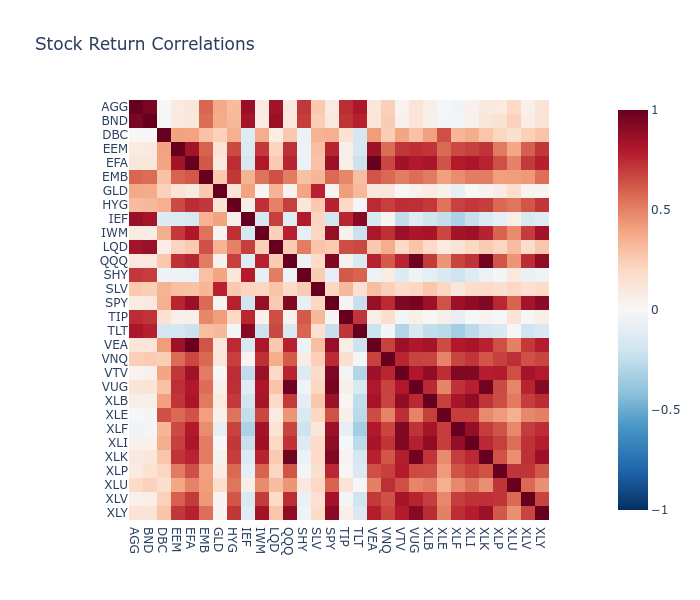

In [13]:
# Compute correlation matrix
corr_matrix = np.corrcoef(returns_matrix.T)

# Interactive correlation heatmap
fig = px.imshow(
    corr_matrix,
    x=selected_stocks,
    y=selected_stocks,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Stock Return Correlations",
)
fig.update_layout(height=600, width=700)
fig.show()

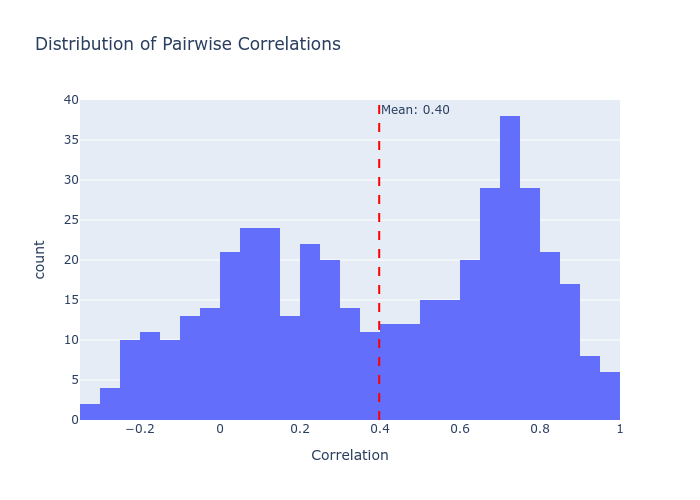

Correlation stats: Mean=0.398, Std=0.345


In [14]:
# Correlation distribution (lower triangle)
lower_tri = corr_matrix[np.tril_indices(len(corr_matrix), -1)]

fig = px.histogram(
    x=lower_tri,
    nbins=30,
    title="Distribution of Pairwise Correlations",
    labels={"x": "Correlation", "y": "Count"},
)
fig.add_vline(
    x=lower_tri.mean(),
    line_dash="dash",
    line_color="red",
    annotation_text=f"Mean: {lower_tri.mean():.2f}",
)
fig.update_layout(showlegend=False)
fig.show()

print(f"Correlation stats: Mean={lower_tri.mean():.3f}, Std={lower_tri.std():.3f}")

**Interpretation**: The average pairwise correlation is well below one, which is
the raw material that makes diversification possible. But the dispersion matters
too: if correlations spike together in stress periods, MVO can overstate how much
protection the cross-section really provides.

### Condition Number & Matrix Analysis

The **condition number** quantifies matrix sensitivity to perturbations. For the covariance matrix:

$$\kappa(\Sigma) = \frac{\sigma_{\text{max}}}{\sigma_{\text{min}}}$$

- **~1**: Well-conditioned (stable)
- **100-1000**: Moderate sensitivity
- **>1000**: Ill-conditioned (may need regularization)

In [15]:
condition_number = np.linalg.cond(annualized_cov)
print(f"Condition number: {condition_number:.1f}")

if condition_number < 100:
    print("-> Well-conditioned matrix (stable optimization)")
elif condition_number < 1000:
    print("-> Moderately conditioned (acceptable for optimization)")
else:
    print("-> Ill-conditioned (consider regularization)")

Condition number: 13583.0
-> Ill-conditioned (consider regularization)


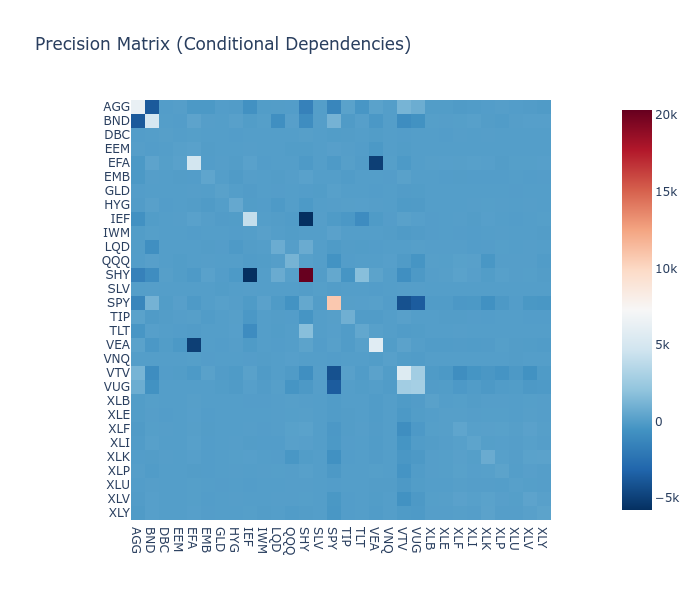

In [16]:
# Precision matrix (inverse of covariance)
# Non-zero off-diagonal elements indicate conditional dependencies
precision_matrix = inv(annualized_cov)

fig = px.imshow(
    precision_matrix,
    x=selected_stocks,
    y=selected_stocks,
    color_continuous_scale="RdBu_r",
    title="Precision Matrix (Conditional Dependencies)",
)
fig.update_layout(height=600, width=700)
fig.show()

## Simulate Random Portfolios

Generate random portfolio weights using the Dirichlet distribution to visualize the feasible region (the "Markowitz Bullet").

In [17]:
def simulate_portfolios(
    returns: np.ndarray,
    cov: np.ndarray,
    n_portfolios: int,
    rf_rate: float = 0.0,
) -> tuple[pl.DataFrame, np.ndarray]:
    """Simulate random long-only portfolios using a Dirichlet distribution."""
    n_assets = len(returns)

    # Generate weights (small alpha = concentrated, large alpha = uniform)
    alpha = np.full(n_assets, 0.05)
    weights = dirichlet(alpha=alpha, size=n_portfolios)

    # Portfolio metrics
    pf_returns = weights @ returns
    pf_std = np.sqrt((weights @ cov * weights).sum(axis=1))
    pf_sharpe = (pf_returns - rf_rate) / pf_std

    results = pl.DataFrame(
        {
            "std": pf_std,
            "return": pf_returns,
            "sharpe": pf_sharpe,
        }
    )

    return results, weights

In [18]:
simulated, sim_weights = simulate_portfolios(
    annualized_returns,
    annualized_cov,
    N_PORTFOLIOS,
    rf_rate=risk_free_rate,
)

simulated.describe()

statistic,std,return,sharpe
str,f64,f64,f64
"""count""",10000.0,10000.0,10000.0
"""null_count""",0.0,0.0,0.0
"""mean""",0.139184,0.065313,0.138376
"""std""",0.045193,0.031444,0.225787
"""min""",0.014992,-0.003559,-1.991034
"""25%""",0.104964,0.042732,0.022321
"""50%""",0.142998,0.060937,0.150282
"""75%""",0.173209,0.08299,0.277118
"""max""",0.299774,0.197332,0.695129


### Interactive Markowitz Bullet

In [19]:
# Convert to pandas for plotly express
sim_pd = simulated.to_pandas()

fig = px.scatter(
    sim_pd.sample(n=min(10000, len(sim_pd)), random_state=42),  # Sample for performance
    x="std",
    y="return",
    color="sharpe",
    color_continuous_scale="Blues",
    opacity=0.5,
    title=f"{N_PORTFOLIOS:,} Simulated Portfolios (Markowitz Bullet)",
    labels={
        "std": "Annualized Volatility",
        "return": "Annualized Return",
        "sharpe": "Sharpe Ratio",
    },
)

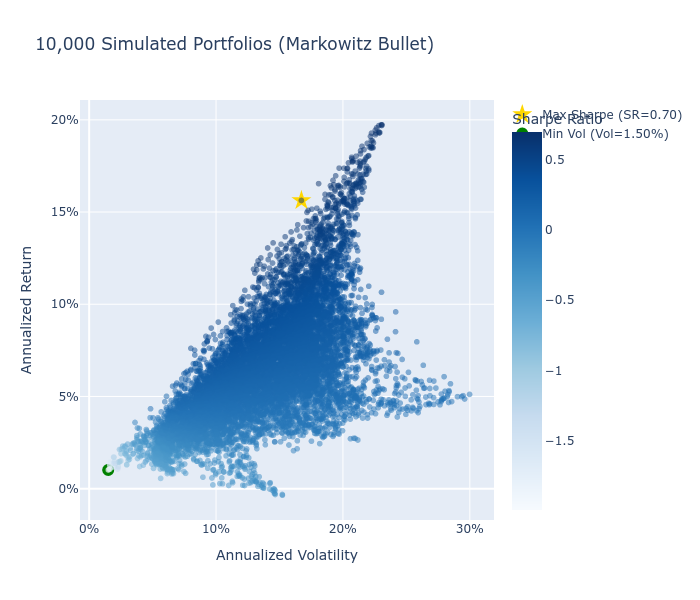

Simulated Max Sharpe: Return=15.63%, Vol=16.73%, SR=0.70
Simulated Min Vol:    Return=1.02%, Vol=1.50%, SR=-1.99


In [20]:
# Mark best portfolios from simulation
max_sharpe_idx = simulated["sharpe"].arg_max()
min_vol_idx = simulated["std"].arg_min()

max_sr = simulated.row(max_sharpe_idx)
min_vol = simulated.row(min_vol_idx)

fig.add_scatter(
    x=[max_sr[0]],
    y=[max_sr[1]],
    mode="markers",
    marker=dict(size=15, color="gold", symbol="star"),
    name=f"Max Sharpe (SR={max_sr[2]:.2f})",
)
fig.add_scatter(
    x=[min_vol[0]],
    y=[min_vol[1]],
    mode="markers",
    marker=dict(size=12, color="green", symbol="circle"),
    name=f"Min Vol (Vol={min_vol[0]:.2%})",
)

fig.update_layout(
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=600,
)
fig.show()

print(f"Simulated Max Sharpe: Return={max_sr[1]:.2%}, Vol={max_sr[0]:.2%}, SR={max_sr[2]:.2f}")
print(f"Simulated Min Vol:    Return={min_vol[1]:.2%}, Vol={min_vol[0]:.2%}, SR={min_vol[2]:.2f}")

**Interpretation**: The random cloud is useful as a sanity check. If the optimizer
lands only marginally better than a broad sample of random portfolios, the extra
precision of MVO is not buying much practical advantage.

## Portfolio Optimization

Now we solve for optimal portfolios using scipy.optimize.

In [21]:
def portfolio_return(weights: np.ndarray, returns: np.ndarray) -> float:
    """Portfolio expected return."""
    return weights @ returns

#### Portfolio Volatility Function

In [22]:
def portfolio_volatility(weights: np.ndarray, cov: np.ndarray) -> float:
    """Portfolio volatility (standard deviation)."""
    return np.sqrt(weights @ cov @ weights)

#### Sharpe Ratio Function

In [23]:
def portfolio_sharpe(weights: np.ndarray, returns: np.ndarray, cov: np.ndarray, rf: float) -> float:
    """Portfolio Sharpe ratio."""
    ret = portfolio_return(weights, returns)
    vol = portfolio_volatility(weights, cov)
    return (ret - rf) / vol

#### Optimization Objective (Negative Sharpe)

In [24]:
def neg_sharpe(weights: np.ndarray, returns: np.ndarray, cov: np.ndarray, rf: float) -> float:
    """Negative Sharpe (for minimization)."""
    return -portfolio_sharpe(weights, returns, cov, rf)

In [25]:
# Optimization constraints and initial guess
n_assets = len(selected_stocks)
# Net-exposure budget: weights sum to 1 (long-only, so |w| == w).
weight_sum_constraint = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

# Initial uniform weights
x0 = np.full(n_assets, 1 / n_assets)

### Maximum Sharpe Ratio Portfolio

In [26]:
def optimize_max_sharpe(returns: np.ndarray, cov: np.ndarray, rf: float):
    """Find long-only portfolio that maximizes Sharpe ratio."""
    bounds = ((0, 1),) * len(returns)

    result = minimize(
        neg_sharpe,
        x0=x0,
        args=(returns, cov, rf),
        method="SLSQP",
        bounds=bounds,
        constraints=weight_sum_constraint,
        options={"ftol": 1e-10, "maxiter": 10000},
    )
    return result


max_sharpe_result = optimize_max_sharpe(annualized_returns, annualized_cov, risk_free_rate)
max_sharpe_weights = max_sharpe_result.x

print(f"Optimization success: {max_sharpe_result.success}")
print(f"Max Sharpe Return: {portfolio_return(max_sharpe_weights, annualized_returns):.2%}")
print(f"Max Sharpe Vol:    {portfolio_volatility(max_sharpe_weights, annualized_cov):.2%}")
print(
    f"Max Sharpe SR:     {portfolio_sharpe(max_sharpe_weights, annualized_returns, annualized_cov, risk_free_rate):.3f}"
)

Optimization success: True
Max Sharpe Return: 17.23%
Max Sharpe Vol:    18.83%
Max Sharpe SR:     0.703


### Minimum Volatility Portfolio

In [27]:
def optimize_min_vol(returns: np.ndarray, cov: np.ndarray):
    """Find long-only minimum volatility portfolio."""
    bounds = ((0, 1),) * len(returns)

    result = minimize(
        portfolio_volatility,
        x0=x0,
        args=(cov,),
        method="SLSQP",
        bounds=bounds,
        constraints=weight_sum_constraint,
        options={"ftol": 1e-10, "maxiter": 10000},
    )
    return result


min_vol_result = optimize_min_vol(annualized_returns, annualized_cov)
min_vol_weights = min_vol_result.x

print(f"Min Vol Return: {portfolio_return(min_vol_weights, annualized_returns):.2%}")
print(f"Min Vol Vol:    {portfolio_volatility(min_vol_weights, annualized_cov):.2%}")
print(
    f"Min Vol SR:     {portfolio_sharpe(min_vol_weights, annualized_returns, annualized_cov, risk_free_rate):.3f}"
)

Min Vol Return: 1.10%
Min Vol Vol:    1.44%
Min Vol SR:     -2.019


### Alternative Portfolio Strategies

In [28]:
# Equal Weight Portfolio
equal_weights = np.full(n_assets, 1 / n_assets)

# Inverse Volatility Portfolio
asset_vols = np.sqrt(np.diag(annualized_cov))
inv_vol_weights = (1 / asset_vols) / (1 / asset_vols).sum()

#### Equal Risk Contribution (ERC)

The ERC portfolio equalizes each asset's percentage contribution to total
portfolio variance. The (percentage) variance contribution for asset $i$ is
$$RC_i = \frac{w_i\,(\Sigma w)_i}{w^\top \Sigma w}.$$
These contributions sum to one across assets; we minimize the squared
deviations of the unnormalized contributions $w_i (\Sigma w)_i$ from the
target $\sigma_P^2 / N$, which is the same as targeting $RC_i = 1/N$.

In [29]:
def equal_risk_contribution(cov: np.ndarray) -> np.ndarray:
    """Compute Equal Risk Contribution weights via optimization.

    Solves for weights where each asset contributes equally to total
    portfolio variance: w_i * (Sigma @ w)_i = sigma_P^2 / N for all i.
    """
    n = len(cov)

    def risk_contrib_objective(w):
        port_var = w @ cov @ w
        marginal_contrib = cov @ w
        risk_contrib = w * marginal_contrib
        target = port_var / n
        return np.sum((risk_contrib - target) ** 2)

    w0 = np.ones(n) / n
    result = minimize(
        risk_contrib_objective,
        w0,
        method="SLSQP",
        bounds=[(1e-6, 1)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"ftol": 1e-12, "maxiter": 10000},
    )
    return result.x


erc_weights = equal_risk_contribution(annualized_cov)

In [30]:
# Store all portfolio strategies
portfolios = {
    "Max Sharpe": max_sharpe_weights,
    "Min Volatility": min_vol_weights,
    "Equal Weight": equal_weights,
    "Inverse Vol": inv_vol_weights,
    "ERC": erc_weights,
}

In [31]:
# Compute metrics for all portfolios
portfolio_metrics = []

for name, weights in portfolios.items():
    ret = portfolio_return(weights, annualized_returns)
    vol = portfolio_volatility(weights, annualized_cov)
    sr = portfolio_sharpe(weights, annualized_returns, annualized_cov, risk_free_rate)
    n_positions = (np.abs(weights) > 0.001).sum()

    portfolio_metrics.append(
        {
            "Portfolio": name,
            "Return": ret,
            "Volatility": vol,
            "Sharpe": sr,
            "Positions": n_positions,
        }
    )

metrics_df = pl.DataFrame(portfolio_metrics)
metrics_df

Portfolio,Return,Volatility,Sharpe,Positions
str,f64,f64,f64,i64
"""Max Sharpe""",0.172326,0.188347,0.702564,2
"""Min Volatility""",0.011018,0.014354,-2.019126,3
"""Equal Weight""",0.065196,0.11794,0.213631,30
"""Inverse Vol""",0.040913,0.06915,0.013201,30
"""ERC""",0.04008,0.071246,0.001125,30


**Interpretation**: This table gives a first read on the return/risk trade-off across
strategies. Notice that Min Volatility can have a negative Sharpe when the optimized
return falls below the risk-free rate -- the optimizer minimizes variance without
regard to the hurdle rate. Equal Risk Contribution (ERC) produces weights that differ
from Inverse Vol because it accounts for cross-asset correlations, not just standalone
volatility.

## Efficient Frontier

In [32]:
def compute_efficient_frontier(
    returns: np.ndarray,
    cov: np.ndarray,
    n_points: int = 50,
) -> pl.DataFrame:
    """Compute long-only efficient frontier by minimizing volatility for target returns."""
    # Return range from min to max achievable
    ret_min = returns.min()
    ret_max = returns.max()
    target_returns = np.linspace(ret_min * 0.5, ret_max * 1.1, n_points)

    bounds = ((0, 1),) * len(returns)
    frontier_points = []

    for target in target_returns:
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, t=target: portfolio_return(w, returns) - t},
        ]

        result = minimize(
            portfolio_volatility,
            x0=x0,
            args=(cov,),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 10000},
        )

        if result.success:
            frontier_points.append(
                {
                    "target_return": target,
                    "volatility": result.fun,
                }
            )

    return pl.DataFrame(frontier_points)

In [33]:
frontier = compute_efficient_frontier(annualized_returns, annualized_cov, n_points=40)
frontier.head()

target_return,volatility
f64,f64
-0.00229,0.130859
0.003483,0.071848
0.009257,0.016953
0.01503,0.015422
0.020803,0.018916


### Plot: Efficient Frontier with All Portfolios

We build the figure incrementally so each visual layer is easy to reason
about: first the random-portfolio cloud, then the efficient frontier curve,
then the named portfolio markers, and finally the layout.

#### Layer A: Simulated-Portfolio Cloud

A subsample of the Dirichlet-generated portfolios provides a visual sanity
check on the feasible region (the "Markowitz bullet").

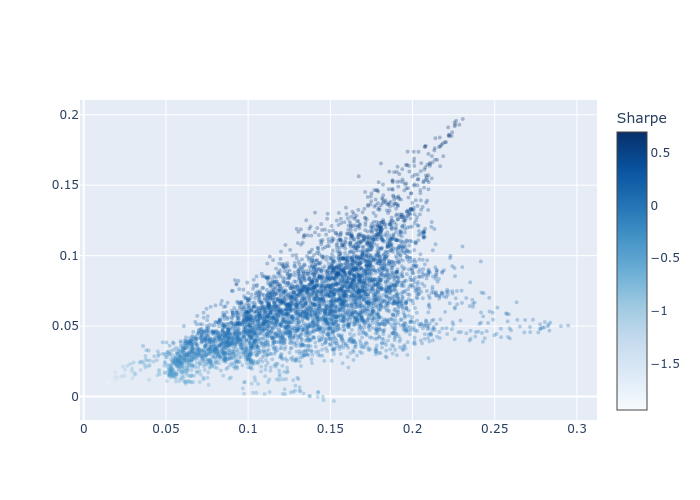

In [34]:
fig = go.Figure()

# Simulated portfolios (sample for performance)
sample_idx = np.random.choice(len(simulated), min(5000, len(simulated)), replace=False)
fig.add_scatter(
    x=simulated["std"].to_numpy()[sample_idx],
    y=simulated["return"].to_numpy()[sample_idx],
    mode="markers",
    marker=dict(
        size=4,
        color=simulated["sharpe"].to_numpy()[sample_idx],
        colorscale="Blues",
        opacity=0.3,
        colorbar=dict(title="Sharpe"),
    ),
    name="Simulated Portfolios",
)

#### Layer B: Efficient Frontier Line

Overlay the optimized frontier — the upper boundary of the feasible region.

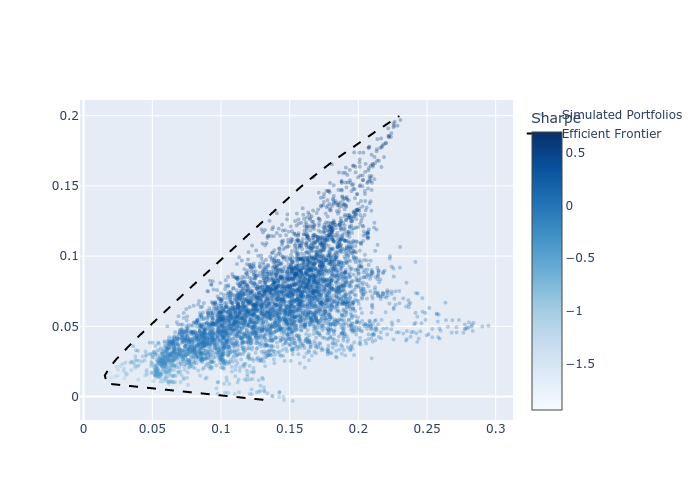

In [35]:
# Efficient frontier
fig.add_scatter(
    x=frontier["volatility"].to_list(),
    y=frontier["target_return"].to_list(),
    mode="lines",
    line=dict(color="black", width=2, dash="dash"),
    name="Efficient Frontier",
)

#### Layer C: Named Portfolio Markers

Add the headline portfolios (Max Sharpe, Min Volatility, Equal Weight,
Inverse Vol, ERC) so we can locate them relative to the frontier.

In [36]:
# Portfolio markers
markers = {
    "Max Sharpe": ("star", "gold", 18),
    "Min Volatility": ("circle", "green", 14),
    "Equal Weight": ("pentagon", "purple", 12),
    "Inverse Vol": ("x", "red", 12),
    "ERC": ("triangle-down", "orange", 12),
}

for name, weights in portfolios.items():
    ret = portfolio_return(weights, annualized_returns)
    vol = portfolio_volatility(weights, annualized_cov)
    symbol, color, size = markers[name]

    fig.add_scatter(
        x=[vol],
        y=[ret],
        mode="markers",
        marker=dict(symbol=symbol, color=color, size=size, line=dict(width=1, color="black")),
        name=name,
    )

#### Layer D: Layout and Render

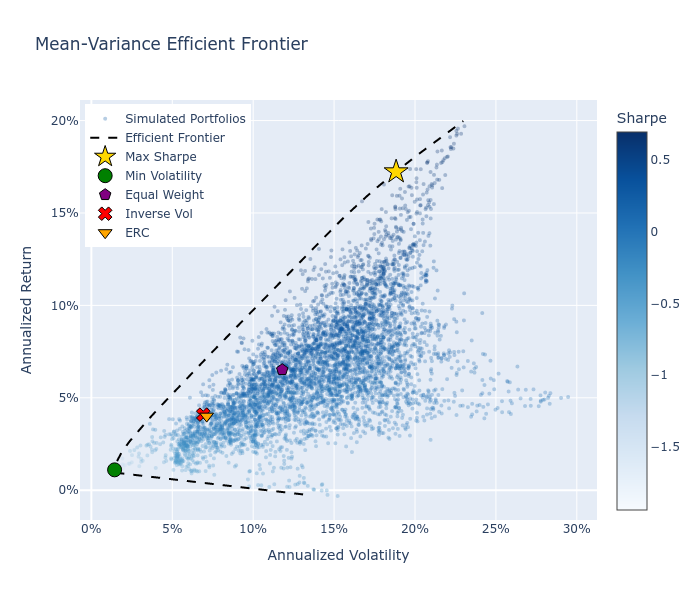

In [37]:
fig.update_layout(
    title="Mean-Variance Efficient Frontier",
    xaxis_title="Annualized Volatility",
    yaxis_title="Annualized Return",
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

**Interpretation**: The efficient frontier traces the upper boundary of the feasible region --
portfolios on this curve deliver the highest return for each level of volatility. Several
patterns are worth noting:

- The **Max Sharpe** portfolio sits on the steepest ray from the risk-free rate to the frontier,
  but it concentrates heavily in a handful of assets, making it sensitive to estimation error.
- The **Min Volatility** portfolio clusters at the left tip of the bullet, dominated by
  short-duration Treasury exposure (SHY ≈ 98% of the weight). It sacrifices return for
  stability and ends up earning less than the risk-free rate.
- **Equal Weight**, **Inverse Vol**, and **ERC** fall inside the frontier -- they are suboptimal
  in-sample by construction -- yet in practice they often match or beat MVO out-of-sample
  because they avoid concentrating on noisy return estimates.

This gap between in-sample optimality and out-of-sample robustness is the **Markowitz Curse**:
the optimizer exploits estimation errors in expected returns, producing portfolios with
strong in-sample efficient-frontier statistics that degrade out-of-sample under parameter
uncertainty. Section 17.5 discusses shrinkage and constraint-based remedies.

### Portfolio Weights Comparison

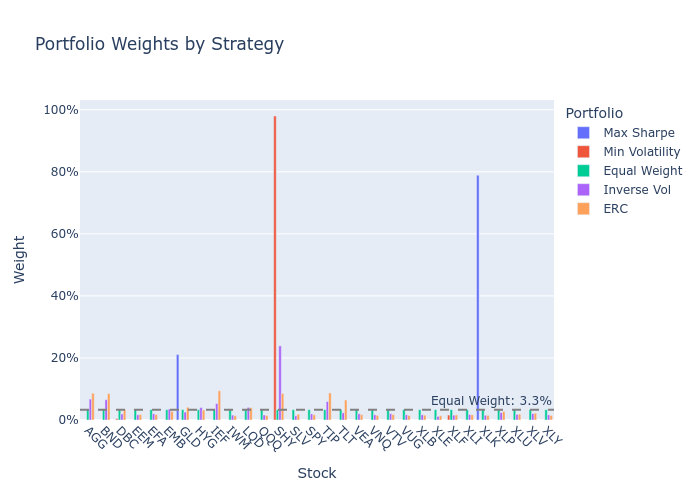

In [38]:
# Create weights DataFrame
weights_df = pl.DataFrame({"Stock": selected_stocks, **portfolios})

# Melt for plotting
weights_long = weights_df.unpivot(index="Stock", variable_name="Portfolio", value_name="Weight")

fig = px.bar(
    weights_long.to_pandas(),
    x="Stock",
    y="Weight",
    color="Portfolio",
    barmode="group",
    title="Portfolio Weights by Strategy",
)

# Add equal weight reference line
fig.add_hline(
    y=1 / n_assets,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Equal Weight: {1 / n_assets:.1%}",
)

fig.update_layout(
    yaxis_tickformat=".0%",
    height=500,
    xaxis_tickangle=45,
)
fig.show()

In [39]:
# Number of significant positions (>0.1%)
for name, weights in portfolios.items():
    n_pos = (np.abs(weights) > 0.001).sum()
    top_weight = np.max(weights)
    print(f"{name:15s}: {n_pos:2d} positions, max weight: {top_weight:.1%}")

Max Sharpe     :  2 positions, max weight: 78.9%
Min Volatility :  3 positions, max weight: 98.0%
Equal Weight   : 30 positions, max weight: 3.3%
Inverse Vol    : 30 positions, max weight: 23.9%
ERC            : 30 positions, max weight: 9.4%


**Interpretation**: This is where the Markowitz curse becomes concrete. The max-Sharpe
solution often wins in-sample by concentrating hard in a few names, while inverse-vol
and equal-weight keep diversification by construction.

## Backtest Portfolio Performance

Now we use **ml4t-diagnostic** to analyze historical portfolio performance with the optimized weights.

In [40]:
# Compute daily portfolio returns for each strategy
daily_ret_np = returns_matrix  # Shape: (n_days, n_assets)
dates = daily_returns["timestamp"].to_list()

portfolio_daily_returns = {}
for name, weights in portfolios.items():
    pf_ret = daily_ret_np @ weights
    portfolio_daily_returns[name] = pf_ret

# Create DataFrame of portfolio returns
pf_returns_df = pl.DataFrame(
    {
        "timestamp": dates,
        **portfolio_daily_returns,
    }
)

pf_returns_df.head()

timestamp,Max Sharpe,Min Volatility,Equal Weight,Inverse Vol,ERC
datetime[μs],f64,f64,f64,f64,f64
2015-01-05 00:00:00,-0.008861,-0.000396,-0.008916,-0.004198,-0.002647
2015-01-06 00:00:00,-0.007106,0.000179,-0.003374,-0.001032,0.000387
2015-01-07 00:00:00,0.005437,0.000604,0.007837,0.004736,0.004126
2015-01-08 00:00:00,0.016452,0.00014,0.008993,0.004452,0.003255
2015-01-09 00:00:00,-0.000075,0.000588,-0.002653,-0.000451,0.000491


### Cumulative Returns Comparison

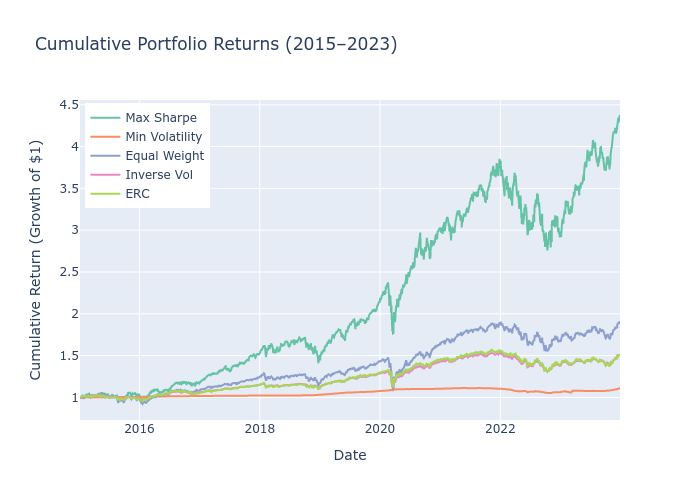

In [41]:
# Compute cumulative returns
fig = go.Figure()

colors = px.colors.qualitative.Set2

for i, name in enumerate(portfolios.keys()):
    cum_ret = (1 + np.array(portfolio_daily_returns[name])).cumprod()
    fig.add_scatter(
        x=dates,
        y=cum_ret,
        mode="lines",
        name=name,
        line=dict(color=colors[i % len(colors)]),
    )

fig.update_layout(
    title=f"Cumulative Portfolio Returns ({START[:4]}\u2013{END[:4]})",
    xaxis_title="Date",
    yaxis_title="Cumulative Return (Growth of $1)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

### Portfolio Analysis with ml4t-diagnostic

In [42]:
# Analyze Max Sharpe portfolio in detail
max_sharpe_returns = pl.Series("returns", portfolio_daily_returns["Max Sharpe"])

analysis = PortfolioAnalysis(
    returns=max_sharpe_returns,
    dates=pl.Series("timestamp", dates),
    risk_free=risk_free_rate,  # Annual risk-free rate
    periods_per_year=252,
)

# Get comprehensive metrics
metrics = analysis.compute_summary_stats()
print(metrics.summary())

Portfolio Performance Summary

Returns
------------------------------
  Total Return:           335.23%
  Annual Return:           17.79%
  Annual Volatility:       18.83%

Risk-Adjusted Returns
------------------------------
  Sharpe Ratio:             0.756
  Sortino Ratio:            0.726
  Calmar Ratio:             0.626
  Omega Ratio:              1.196
  Tail Ratio:               0.974

Risk Metrics
------------------------------
  Max Drawdown:           -28.41%
  VaR (95%):               -1.83%
  CVaR (95%):              -2.75%

Distribution
------------------------------
  Skewness:                -0.200
  Kurtosis:                 9.785
  Stability (R²):           0.918

Win/Loss
------------------------------
  Win Rate:                55.72%
  Profit Factor:             1.20
  Avg Win:                  0.79%
  Avg Loss:                -0.83%


### Factor Decomposition with `ml4t-diagnostic`

`PortfolioAnalysis` reports the standard summary statistics for this
portfolio. `FactorAnalysis` from the same library answers a different
question: "**what is driving** this portfolio's returns?". We regress the
Max-Sharpe daily return series on the Fama-French 5-factor model (Mkt-RF,
SMB, HML, RMW, CMA) using HAC standard errors. The intercept is the
factor-adjusted alpha; the loadings show whether the MVO solution amounts
to a tilt on market, size, value, profitability, or investment beyond what
the historical-mean optimization knows about explicitly.

Because §17.3 anchors the chapter on factor evidence (NB05), this
decomposition closes the loop: it shows whether the optimization output
expresses persistent factor exposures or idiosyncratic stock selection.

In [43]:
ff_data = load_fama_french_5factor(frequency="daily")

mvo_returns_pl = pl.DataFrame(
    {
        "timestamp": pl.Series(dates),
        "ret": np.asarray(portfolio_daily_returns["Max Sharpe"]),
    }
)
joined = mvo_returns_pl.with_columns(pl.col("timestamp").cast(pl.Date)).join(
    ff_data.returns.with_columns(pl.col("timestamp").cast(pl.Date)),
    on="timestamp",
    how="inner",
)
print(
    f"Aligned {joined.height} daily observations with FF5 factors "
    f"({joined['timestamp'].min()} → {joined['timestamp'].max()})"
)

aligned_factor_data = ff_data.__class__(
    returns=joined.select(["timestamp"] + ff_data.factor_names),
    rf_rate=None,
    factor_names=ff_data.factor_names,
    source="fama_french",
    frequency="daily",
)
fa = FactorAnalysis(
    returns=joined["ret"].to_numpy(),
    factor_data=aligned_factor_data,
    periods_per_year=252,
)
factor_model = fa.static_model(hac=True)
print(factor_model.summary())

2026-06-13 00:11:30 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=fama_french


2026-06-13 00:11:30 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-13 00:11:30 [info     ] Initialized Fama-French provider cache_path=data/factors/fama-french name=FamaFrenchProvider use_cache=True


2026-06-13 00:11:30 [debug    ] Loading from cache             file=data/factors/fama-french/ff5_daily.parquet name=FamaFrenchProvider


2026-06-13 00:11:30 [info     ] Fetched Fama-French data       columns=7 dataset=ff5 frequency=daily name=FamaFrenchProvider rows=15770


2026-06-13 00:11:30 [debug    ] HTTP session closed           


2026-06-13 00:11:30 [debug    ] HTTP session closed           


Aligned 2263 daily observations with FF5 factors (2015-01-05 → 2023-12-29)
Factor Model Results
Method: OLS (HAC SEs)
Observations: 2263
R²: 0.9083  Adj R²: 0.9080
Durbin-Watson: 2.031
|t| > 2: 80% of factors

Alpha: 0.000239 (t=3.31, p=0.0009)

Factor              Beta       SE   t-stat  p-value
-------------------------------------------------------
Mkt-RF            0.9404   0.0087   108.68   0.0000
SMB              -0.1315   0.0163    -8.07   0.0000
HML              -0.2881   0.0169   -17.08   0.0000
RMW               0.1476   0.0233     6.33   0.0000
CMA               0.0085   0.0384     0.22   0.8250


Read the table top-down: the **alpha** row is the residual return after
removing factor exposures (annualized, with a HAC t-statistic). The
**factor loadings** report what fraction of each factor's return the
portfolio captures. A high adjusted $R^2$ means the MVO solution is
largely a factor-tilt portfolio — useful information for cost budgeting,
because liquid factor ETFs replicate those tilts at a fraction of the
turnover.

In [44]:
# Compare all portfolio strategies using PortfolioAnalysis
comparison_metrics = []

for name, weights in portfolios.items():
    returns_series = pl.Series("returns", portfolio_daily_returns[name])

    pa = PortfolioAnalysis(
        returns=returns_series,
        dates=pl.Series("timestamp", dates),
        risk_free=risk_free_rate,  # Annual risk-free rate
        periods_per_year=252,
    )

    metrics = pa.compute_summary_stats()

    comparison_metrics.append(
        {
            "Portfolio": name,
            "Annual Return": f"{metrics.annual_return:.2%}",
            "Annual Vol": f"{metrics.annual_volatility:.2%}",
            "Sharpe": f"{metrics.sharpe_ratio:.3f}",
            "Sortino": f"{metrics.sortino_ratio:.3f}",
            "Calmar": f"{metrics.calmar_ratio:.3f}",
            "Max DD": f"{metrics.max_drawdown:.2%}",
            "Win Rate": f"{metrics.win_rate:.2%}",
            "VaR 95%": f"{metrics.var_95:.2%}",
        }
    )

comparison_df = pl.DataFrame(comparison_metrics)
comparison_df

Portfolio,Annual Return,Annual Vol,Sharpe,Sortino,Calmar,Max DD,Win Rate,VaR 95%
str,str,str,str,str,str,str,str,str
"""Max Sharpe""","""17.79%""","""18.83%""","""0.756""","""0.726""","""0.626""","""-28.41%""","""55.72%""","""-1.83%"""
"""Min Volatility""","""1.15%""","""1.44%""","""-1.931""","""-2.016""","""0.203""","""-5.66%""","""52.76%""","""-0.13%"""
"""Equal Weight""","""7.40%""","""11.79%""","""0.332""","""0.311""","""0.291""","""-25.41%""","""54.57%""","""-1.03%"""
"""Inverse Vol""","""4.69%""","""6.92%""","""0.130""","""0.119""","""0.311""","""-15.07%""","""55.94%""","""-0.61%"""
"""ERC""","""4.68%""","""7.12%""","""0.128""","""0.117""","""0.282""","""-16.61%""","""55.77%""","""-0.63%"""


**Interpretation**: Several patterns stand out:

- **Min Volatility** concentrates into short-duration bonds (SHY, BND, IEF) and delivers
  the lowest drawdown, but its return barely exceeds -- and may fall below -- the
  risk-free rate. A negative Sharpe means an investor would have earned more in
  T-bills with zero volatility. This is the optimizer working as designed: it
  minimizes variance regardless of whether the resulting return compensates.
- **Max Sharpe** targets the steepest excess-return-per-unit-risk, but concentrates
  heavily, making it sensitive to estimation error.
- **ERC** and **Inverse Vol** offer middle-ground diversification. Because ERC
  equalizes risk *contributions* (accounting for correlations) rather than simply
  inverting standalone volatility, the two strategies produce different weights and metrics.

### Execution-Aware Bridge with ml4t-backtest

The vectorized returns above isolate allocation logic. To connect this directly to
deployment mechanics, run the same target weights through `ml4t-backtest` with
next-bar execution, commission, and slippage.

Submit the optimized target weights once, then let the engine handle fills and costs.

In [45]:
class StaticWeightStrategy(Strategy):
    def __init__(self, target_weights: dict[str, float], allow_short: bool):
        self.target_weights = target_weights
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.001,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )
        self._submitted = False

    def on_data(self, timestamp, data, context, broker):
        if self._submitted:
            return
        targets = {asset: weight for asset, weight in self.target_weights.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)
            self._submitted = True

In [46]:
# Build engine inputs from the max-Sharpe portfolio and the historical price panel.
engine_target_weights = {
    asset: float(weight)
    for asset, weight in zip(selected_stocks, portfolios["Max Sharpe"], strict=False)
    if abs(float(weight)) > 1e-8
}
allow_short_engine = any(weight < 0 for weight in engine_target_weights.values())

prices_panel = pl.from_pandas(prices_pd.reset_index())
prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1_000_000).alias("volume"),
        ]
    )
    .sort(["timestamp", "symbol"])
)

In [47]:
# Run the engine and collect daily returns for an apples-to-apples comparison.
engine = Engine(
    feed=DataFeed(prices_df=prices_long),
    strategy=StaticWeightStrategy(engine_target_weights, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.0005,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=allow_short_engine,
    ),
)

engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("timestamp"),
        pl.col("return_pct").alias("engine_return"),
    )
)

vectorized_daily = pl.DataFrame(
    {
        "timestamp": pl.Series(dates).cast(pl.Datetime("us")),
        "vectorized_return": np.asarray(portfolio_daily_returns["Max Sharpe"]),
    }
)

In [48]:
# Compare vectorized and execution-aware performance on overlapping dates.
bridge = (
    vectorized_daily.join(engine_daily, on="timestamp", how="inner")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("timestamp")
)

vectorized_pa = PortfolioAnalysis(
    returns=bridge["vectorized_return"],
    dates=bridge["timestamp"],
    risk_free=risk_free_rate,
    periods_per_year=252,
)
engine_pa = PortfolioAnalysis(
    returns=bridge["engine_return"],
    dates=bridge["timestamp"],
    risk_free=risk_free_rate,
    periods_per_year=252,
)

vectorized_stats = vectorized_pa.compute_summary_stats()
engine_stats = engine_pa.compute_summary_stats()

In [49]:
print("Execution bridge (Max Sharpe):")
print(
    f"  Vectorized Sharpe={vectorized_stats.sharpe_ratio:.3f}, "
    f"Engine Sharpe={engine_stats.sharpe_ratio:.3f}"
)
print(
    f"  Vectorized MaxDD={vectorized_stats.max_drawdown:.2%}, "
    f"Engine MaxDD={engine_stats.max_drawdown:.2%}"
)

Execution bridge (Max Sharpe):
  Vectorized Sharpe=0.756, Engine Sharpe=0.730
  Vectorized MaxDD=-28.41%, Engine MaxDD=-31.52%


In [50]:
bridge_table = pl.DataFrame(
    [
        {
            "Mode": "Vectorized (Max Sharpe)",
            "Annual Return": vectorized_stats.annual_return,
            "Sharpe": vectorized_stats.sharpe_ratio,
            "Max Drawdown": vectorized_stats.max_drawdown,
        },
        {
            "Mode": "ml4t-backtest Engine (Max Sharpe)",
            "Annual Return": engine_stats.annual_return,
            "Sharpe": engine_stats.sharpe_ratio,
            "Max Drawdown": engine_stats.max_drawdown,
        },
    ]
)
bridge_table

Mode,Annual Return,Sharpe,Max Drawdown
str,f64,f64,f64
"""Vectorized (Max Sharpe)""",0.177945,0.755845,-0.28415
"""ml4t-backtest Engine (Max Shar…",0.182335,0.729589,-0.315193


The table makes it easy to separate ranking changes from mere scale changes. A small
return haircut may be acceptable; a collapse in Sharpe usually signals that the raw
optimization was leaning on unrealistically precise weights.

**Interpretation**: The bridge makes the implementation gap explicit. If the engine
materially degrades Sharpe or drawdown, the optimizer is producing weights that look
better in frictionless arithmetic than they do under realistic execution.

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


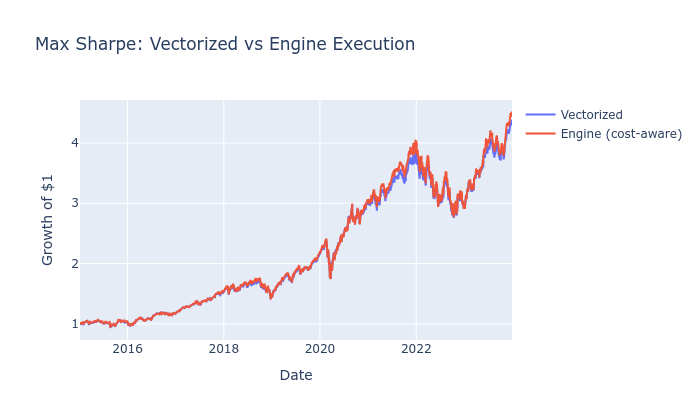

In [51]:
fig = go.Figure()
fig.add_scatter(
    x=bridge["timestamp"],
    y=(1 + bridge["vectorized_return"]).cum_prod(),
    mode="lines",
    name="Vectorized",
)
fig.add_scatter(
    x=bridge["timestamp"],
    y=(1 + bridge["engine_return"]).cum_prod(),
    mode="lines",
    name="Engine (cost-aware)",
)
fig.update_layout(
    title="Max Sharpe: Vectorized vs Engine Execution",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=420,
)
fig.show()

### Drawdown Analysis

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


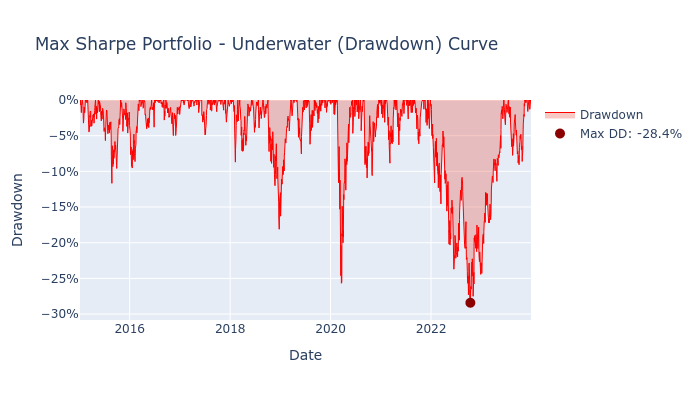

In [52]:
# Drawdown for Max Sharpe portfolio
cum_returns = (1 + np.array(portfolio_daily_returns["Max Sharpe"])).cumprod()
running_max = np.maximum.accumulate(cum_returns)
drawdown = (cum_returns - running_max) / running_max

fig = go.Figure()

fig.add_scatter(
    x=dates,
    y=drawdown,
    mode="lines",
    fill="tozeroy",
    fillcolor="rgba(231, 76, 60, 0.3)",
    line=dict(color="red", width=1),
    name="Drawdown",
)

# Mark maximum drawdown
max_dd_idx = np.argmin(drawdown)
fig.add_scatter(
    x=[dates[max_dd_idx]],
    y=[drawdown[max_dd_idx]],
    mode="markers",
    marker=dict(size=10, color="darkred"),
    name=f"Max DD: {drawdown[max_dd_idx]:.1%}",
)

fig.update_layout(
    title="Max Sharpe Portfolio - Underwater (Drawdown) Curve",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    yaxis_tickformat=".0%",
    height=400,
)
fig.show()

**Interpretation**: The underwater curve is the investor-experience view of MVO.
A portfolio with a strong average Sharpe can still be hard to hold if losses cluster
into a small number of deep and persistent drawdowns.

### Portfolio Metrics Visualization

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


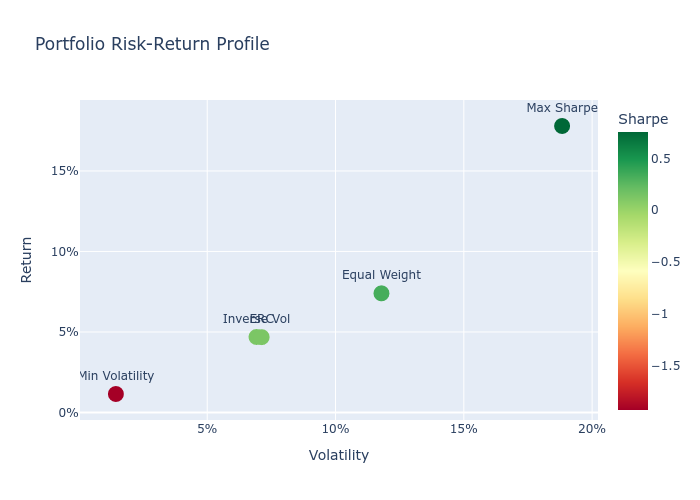

In [53]:
# Risk-return scatter colored by Sharpe ratio
metrics_for_plot = []
for name in portfolios.keys():
    row = comparison_df.filter(pl.col("Portfolio") == name).row(0, named=True)
    metrics_for_plot.append(
        {
            "Portfolio": name,
            "Return": float(row["Annual Return"].strip("%")) / 100,
            "Volatility": float(row["Annual Vol"].strip("%")) / 100,
            "Sharpe": float(row["Sharpe"]),
            "MaxDD": float(row["Max DD"].strip("%")) / 100,
        }
    )

plot_df = pl.DataFrame(metrics_for_plot).to_pandas()

fig = px.scatter(
    plot_df,
    x="Volatility",
    y="Return",
    color="Sharpe",
    text="Portfolio",
    size_max=30,
    color_continuous_scale="RdYlGn",
    title="Portfolio Risk-Return Profile",
)

fig.update_traces(textposition="top center", marker=dict(size=16))
fig.update_layout(
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=500,
)
fig.show()

## Key Takeaways

1. **The Markowitz curse is real**: Max Sharpe concentrates into a few assets
   and is fragile to estimation error, while Min Volatility can converge to a
   degenerate solution that underperforms the risk-free rate.
2. **Heuristic baselines are competitive on this universe**: Equal Weight, Inverse
   Volatility, and Equal Risk Contribution portfolios provide diversification without
   inverting a noisy covariance estimate, which is the failure mode of long-only, unregularized
   optimization here.
3. **ERC differs from Inverse Volatility**: By accounting for correlations in risk
   contribution, ERC produces meaningfully different weights and risk profiles
   compared to simple inverse-volatility scaling.
4. **Execution costs matter**: The engine-based backtest shows the gap between
   frictionless arithmetic and realistic fills. Concentrated optimized portfolios
   are more sensitive to this gap.

**Next**: Continue with [`03_robust_optimization`](03_robust_optimization.ipynb) for shrinkage, robust covariance, and
optimization settings that improve out-of-sample behavior.